# Data Quality & Campaign EDA

This notebook validates source integrity and explores campaign performance at the correct grain: one campaign observation, not one verified unique customer.

In [1]:
from pathlib import Path
import hashlib

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
RAW_PATH = ROOT / 'data' / 'raw' / 'bank-additional-full.csv'
PROCESSED_PATH = ROOT / 'data' / 'processed' / 'campaign_observations.csv'
raw = pd.read_csv(RAW_PATH, sep=';')
observations = pd.read_csv(PROCESSED_PATH)

## 1. Source contract
The source must reconcile to 41,188 rows and 21 columns with no native null cells. Exact duplicate observations are retained because no unique customer or campaign identifier exists.

In [2]:
source_hash = hashlib.sha256(RAW_PATH.read_bytes()).hexdigest()
quality_summary = pd.Series({
    'raw_rows': len(raw),
    'raw_columns': raw.shape[1],
    'native_null_cells': int(raw.isna().sum().sum()),
    'exact_duplicate_excess_rows': int(raw.duplicated().sum()),
    'subscriptions': int(raw['y'].eq('yes').sum()),
    'processed_rows': len(observations),
    'unique_campaign_record_ids': observations['campaign_record_id'].nunique(),
    'sha256': source_hash,
}, name='verified_value')
quality_summary

raw_rows                                                                   41188
raw_columns                                                                   21
native_null_cells                                                              0
exact_duplicate_excess_rows                                                   12
subscriptions                                                               4640
processed_rows                                                             41188
unique_campaign_record_ids                                                 41188
sha256                         74adfc578bf77a7ff4bb1ba4a9f8709d9e3c6907342959...
Name: verified_value, dtype: object

## 2. Explicit unknown categories
`unknown` is a valid source category and is not silently converted into a null or fabricated value.

In [3]:
unknown_counts = pd.Series({
    column: int(raw[column].eq('unknown').sum())
    for column in raw.select_dtypes(include='object').columns
    if raw[column].eq('unknown').any()
}, name='unknown_observations').sort_values(ascending=False)
unknown_counts

default      8597
education    1731
housing       990
loan          990
job           330
marital        80
Name: unknown_observations, dtype: int64

## 3. Campaign performance
The charts are descriptive associations. They do not prove that channel or contact frequency caused conversion.

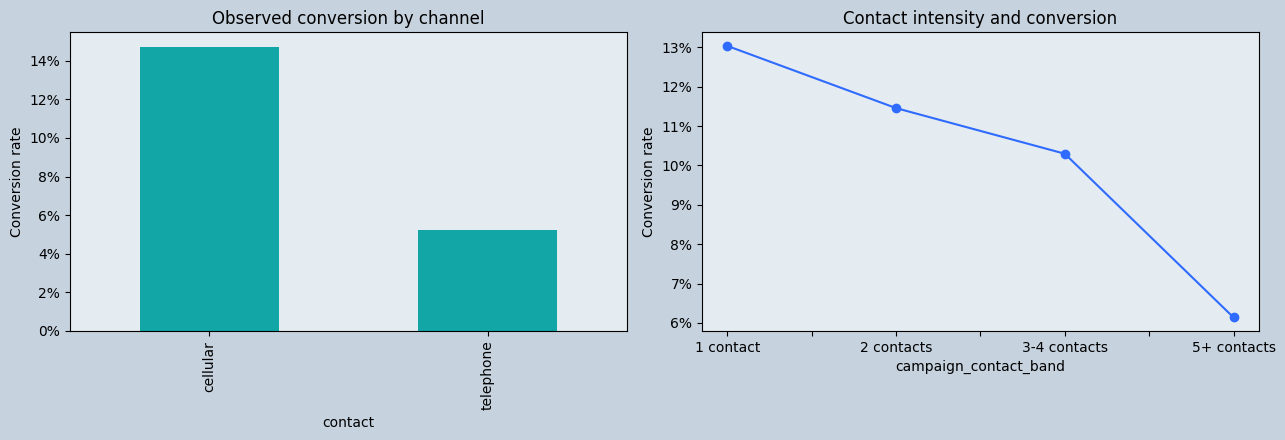

In [4]:
channel = observations.groupby('contact', observed=True)['conversion_flag'].agg(observations='size', conversion_rate='mean')
contact_order = ['1 contact', '2 contacts', '3-4 contacts', '5+ contacts']
intensity = observations.groupby('campaign_contact_band', observed=True)['conversion_flag'].agg(observations='size', conversion_rate='mean').reindex(contact_order)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), facecolor='#CEC8E3')
channel['conversion_rate'].plot.bar(ax=axes[0], color='#13A6A6', title='Observed conversion by channel')
intensity['conversion_rate'].plot(ax=axes[1], marker='o', color='#2F6BFF', title='Contact intensity and conversion')
for axis in axes:
    axis.set_facecolor('#E1DCF0')
    axis.set_ylabel('Conversion rate')
    axis.yaxis.set_major_formatter(lambda value, _: f'{value:.0%}')
plt.tight_layout()
plt.show()

## 4. Reproducibility gate
These assertions prevent the exploratory layer from drifting away from the production data contract.

In [5]:
notebook_assertions = {
    'source_shape': raw.shape == (41188, 21),
    'no_native_nulls': raw.isna().sum().sum() == 0,
    'duplicate_policy_reconciled': raw.duplicated().sum() == 12,
    'subscriptions_reconciled': raw['y'].eq('yes').sum() == 4640,
    'processed_grain_preserved': len(observations) == observations['campaign_record_id'].nunique() == 41188,
    'source_hash_reconciled': source_hash == '74adfc578bf77a7ff4bb1ba4a9f8709d9e3c6907342959c2c8416847e0afb4d8',
}
assert all(notebook_assertions.values()), notebook_assertions
pd.Series(notebook_assertions, name='PASS')

source_shape                   True
no_native_nulls                True
duplicate_policy_reconciled    True
subscriptions_reconciled       True
processed_grain_preserved      True
source_hash_reconciled         True
Name: PASS, dtype: bool